<IPython.core.display.Javascript object>


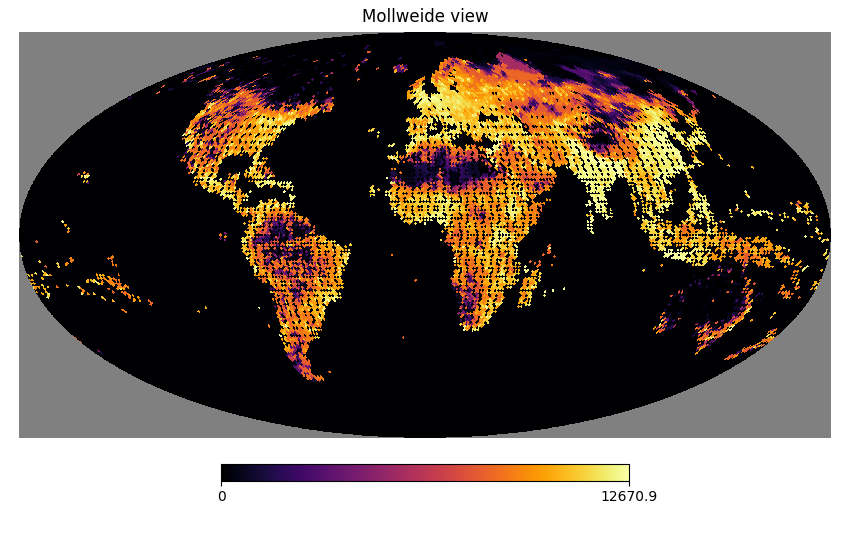

<IPython.core.display.Javascript object>


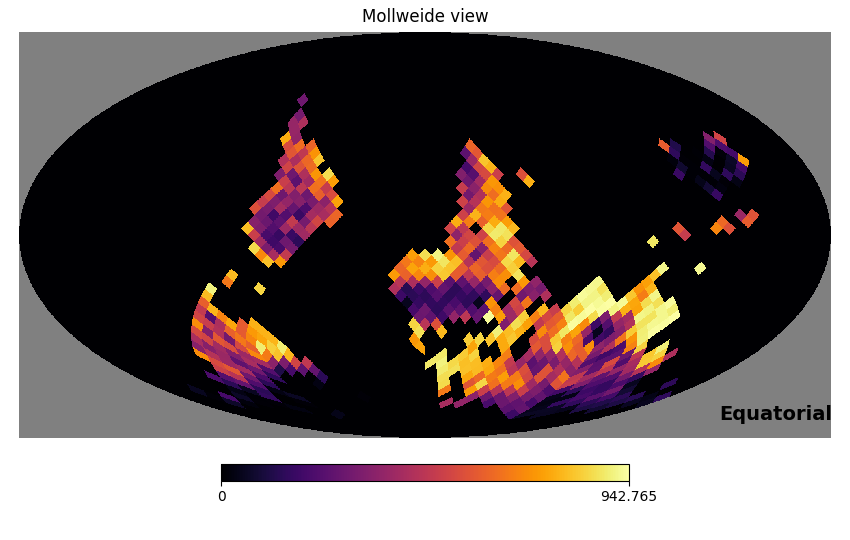

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import healpy as hp

# Read the tif file
image = tiff.imread('/media/sf_Shared_Ubuntu/MAPS/GPW_2020_1deg.tif')
image_array = np.array(image)

# Define the spherical coordinates using WGS84 latitude and longitude#
# Assuming latitude ranges from -90 to 90 and longitude ranges from -180 to 180
n_lat, n_lon = image_array.shape
latitudes = np.linspace(-90, 90, num=n_lat)
longitudes = np.linspace(-180, 180, num=n_lon)

# Convert latitudes to HEALPix theta (polar angle)
theta =( np.radians(90 - latitudes))

# Convert longitudes to HEALPix phi (azimuthal angle)
phi = np.radians(longitudes)

# Set HEALPix parameters
nside = 64

# Make empty HEALPix map and pixel values vector
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)

for i in range(n_lat):
    for j in range(n_lon):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

# Average and assign to HEALPix
healpix_map[pixel_counts > 0] /= pixel_counts[pixel_counts > 0]

# Manually flip the map data vertically
healpix_map_flipped = np.flipud(healpix_map)

# Display the HEALPix map
%matplotlib notebook
hp.mollview(healpix_map_flipped, cmap="inferno", xsize=3000, flip="astro", norm="hist", min=0)
plt.show()

# Perform ud_grade to a lower resolution
healpix_map_ns16 = hp.pixelfunc.ud_grade(healpix_map, 16)

# Display the lower-resolution HEALPix map
%matplotlib notebook
hp.mollview(healpix_map_ns16, cmap="inferno", xsize=2000, coord="C",norm='hist', flip="geo", min=0)
plt.show()
